In [1]:
# tbee must be importable: `pip install -e .` from the repository root
# (recommended), or run this notebook from within examples/ and it will
# find the package via the fallback below.
import sys, os
try:
    import tbee
except ImportError:
    sys.path.insert(0, os.path.abspath('..'))


In [2]:
from tbee.lattice import *
from tbee.system import *
from tbee.plot import *
from tbee.propagation import *
from tbee.save import *
%matplotlib inline

In [3]:
%load_ext autoreload
%autoreload 2

In [4]:
import warnings
warnings.filterwarnings('ignore')

# Dimer Chain + Dimerization Defect

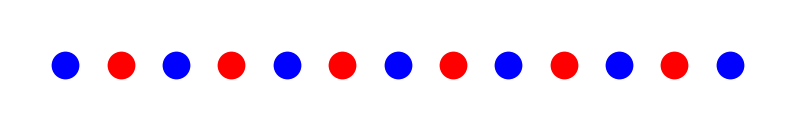

In [5]:
unit_cell = [{'tag': 'a', 'r0': (0., 0.)}, 
             {'tag': 'b', 'r0': (1., 0.)}]
prim_vec = [(2, 0.)]
lat = lattice(unit_cell=unit_cell, prim_vec=prim_vec)
sys = system(lat=lat)
n1 = 7
lat.get_lattice(n1=n1)
lat.remove_sites([13])
lat.plot(figsize=(10, 2));

In [6]:
e_a, e_b = 0j, -1.j
t_ab, t_ba = 2., 1.
sys.set_onsite({'a': e_a, 'b': e_b})
sys.set_hopping([{'n': 1, 'tag': 'ab', 't': t_ab}, 
                 {'n': 1, 'tag': 'ba', 't': t_ba}])
sys.change_hopping_square([{'n': 1, 'tag': 'ab', 't': t_ba}, 
                           {'n': 1, 'tag': 'ba', 't': t_ab}], 
                          xlims=[6., 20.])
sys.get_ham()

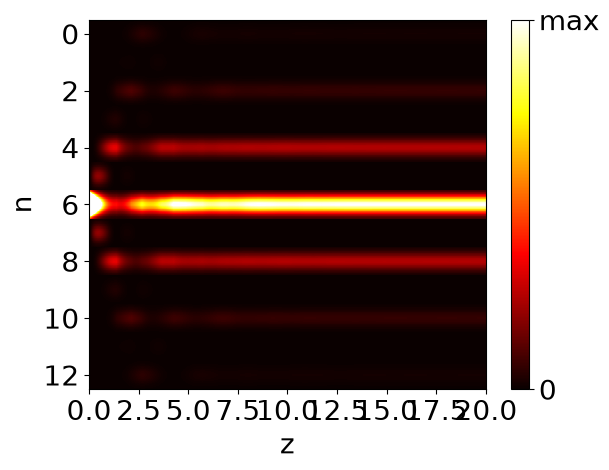

In [7]:
prop = propagation(lat=lat)
psi_init = np.zeros(lat.sites, 'c16')
psi_init[6] = 1
prop.get_propagation(ham=sys.ham, psi_init=psi_init, 
                     steps=2000, dz=0.01, norm=True)
fig_prop = prop.plt_propagation_1d(prop_type='norm');

In [8]:
sav = save(dir_name='chain')
sav.fig(fig_prop, 'propagation')

## Adiabatic Pumping

In [9]:
t_ab, t_ba = 5., 1.

### Configuration 1

In [10]:
sys.set_onsite({'a': e_a, 'b': e_b})
sys.set_hopping([{'n': 1, 'tag': 'ab', 't': t_ab}, 
                 {'n': 1, 'tag': 'ba', 't': t_ba}])
sys.change_hopping_square([{'n': 1, 'tag': 'ab', 't': t_ba}, 
                           {'n': 1, 'tag': 'ba', 't': t_ab}], 
                          xlims=[2., 20.])
sys.get_ham()
ham1 = sys.ham

### Configuration 2

In [11]:
sys.set_onsite({'a': e_a, 'b': e_b})
sys.set_hopping([{'n': 1, 'tag': 'ab', 't': t_ab}, 
                 {'n': 1, 'tag': 'ba', 't': t_ba}])
sys.change_hopping_square([{'n': 1, 'tag': 'ab', 't': t_ba}, 
                           {'n': 1, 'tag': 'ba', 't': t_ab}], 
                          xlims=[10., 20.])
sys.get_ham()
ham2 = sys.ham

### Aiabatic pumping

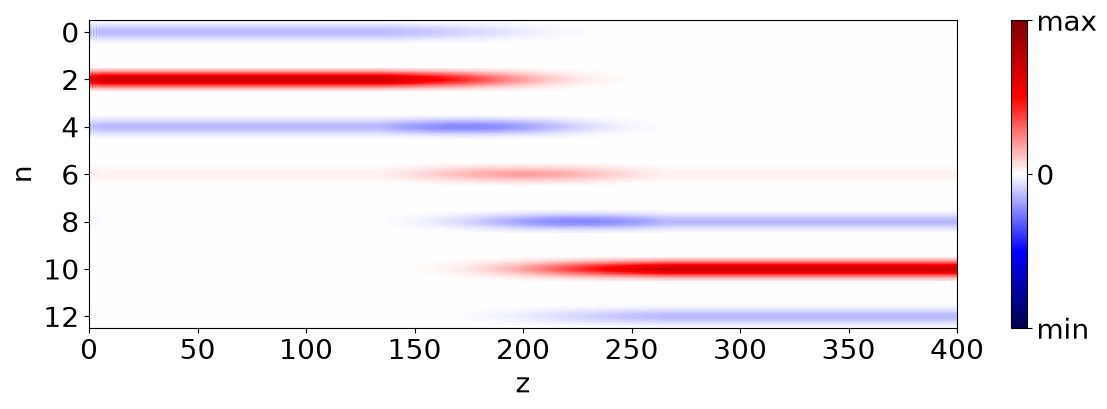

In [12]:
prop = propagation(lat=lat)
psi_init = np.zeros(lat.sites, 'c16')
psi_init[2] = 1.
prop.get_pumping(hams=[ham1, ham2], 
                     psi_init=psi_init,
                     steps=2000, dz=0.2, norm=True)
fig_pumping = prop.plt_propagation_1d(figsize=(14, 4), prop_type='real');

In [13]:
sav.fig(fig_pumping, 'pumping')

# Graphene Placket

In [14]:
from math import pi as PI
from math import cos, sin, sqrt

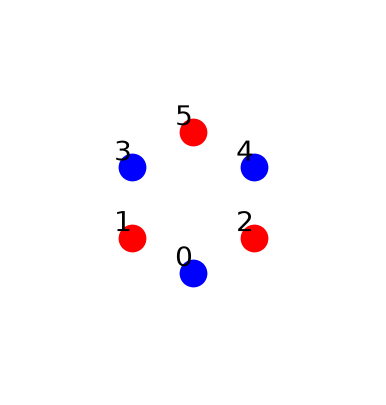

In [15]:
unit_cell = [{'tag': 'a', 'r0': (0., 0.)}, 
             {'tag': 'b', 'r0': (0.5, 0.5/sqrt(3))}]
prim_vec = [(1, 0.), 
            (cos(PI/3), sin(PI/3))]
lat = lattice(unit_cell=unit_cell, prim_vec=prim_vec)
n1, n2 = 2, 2
lat.get_lattice(n1=n1, n2=n2)
lat.remove_dangling()
lat.plot(plt_index=True);

In [16]:
sys = system(lat=lat)
t_1 = 1. 
sys.set_hopping([{'n': 1, 't': t_1}])
sys.get_ham()

## Propagation

### Constructive interferences on site 5

In [17]:
prop = propagation(lat=lat)
psi_init = np.zeros(lat.sites, 'c16')
psi_init[0] = 1.
prop.get_propagation(ham=sys.ham, psi_init=psi_init, 
                     steps=50, dz=0.2, norm=False)

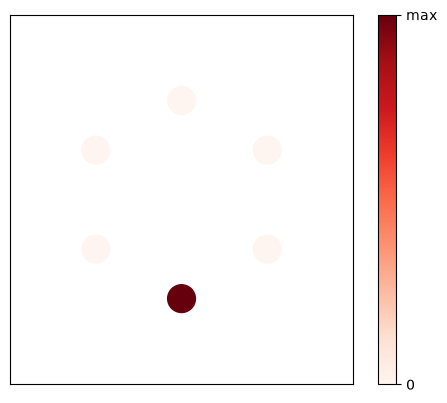

In [18]:
# method to be run
prop.get_animation_nb(s=400., prop_type='norm')

## one negative hopping

In [19]:
sys.set_hopping([{'n': 1, 't': t_1}])
sys.set_hopping_def({(1, 3): -1})
sys.get_ham()

### Destructive interferences on site 5

In [20]:
prop = propagation(lat=lat)
psi_init = np.zeros(lat.sites, 'c16')
psi_init[0] = 1.
prop.get_propagation(ham=sys.ham, psi_init=psi_init, 
                     steps=50, dz=0.2, norm=False)

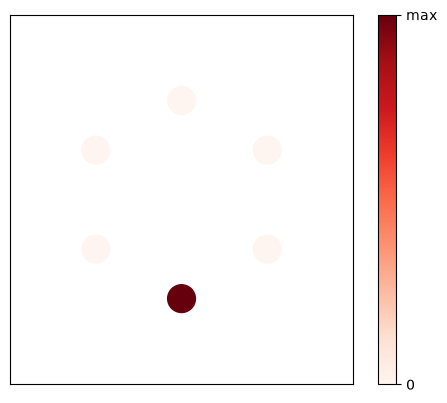

In [21]:
# cell to be run
prop.get_animation_nb(s=400., prop_type='norm')

# Lieb lattice

## Propagation

In [22]:
n1, n2 = 5, 5
unit_cell = [{'tag': 'a', 'r0': (0, 0)},
             {'tag': 'b', 'r0': (1, 0)},
             {'tag': 'c', 'r0': (0, 1)}]
prim_vec = [(2., 0.), (0., 2.)]
lat = lattice(unit_cell=unit_cell, prim_vec=prim_vec)
lat.get_lattice(n1=n1, n2=n2)
lat.remove_dangling()
sys = system(lat=lat)

t_ab, t_ba = 4/3., 2/3.
t_ac, t_ca = 4/3., 2/3.
sys.set_hopping([{'n': 1, 'tag': 'ab', 't': t_ab},
                 {'n': 1, 'tag': 'ba', 't': t_ba},
                 {'n': 1, 'tag': 'ac', 't': t_ac},
                 {'n': 1, 'tag': 'ca', 't': t_ca}])
sys.set_onsite({'a': 0j, 'b': -2j, 'c': -2j})
# Dimerization along x
list_hop = [{'n': 1, 'tag': 'ab', 't': t_ba},
            {'n': 1, 'tag': 'ba', 't': t_ab}]
sys.change_hopping_square(list_hop=list_hop, 
                          xlims=[4., 8.], 
                          ylims=[0., 8.])
# Dimerization along y
list_hop = [{'n': 1, 'tag': 'ac', 't': t_ca},
            {'n': 1, 'tag': 'ca', 't': t_ac}]
sys.change_hopping_square(list_hop=list_hop,
                   xlims=[0., 8.], 
                   ylims=[4., 8.])

sys.get_ham()
prop = propagation(lat=lat)
psi_init = np.ones(lat.sites, 'c16') / np.sqrt(lat.sites)
prop.get_propagation(ham=sys.ham, psi_init=psi_init,
                     steps=50, dz=0.2, norm=True)

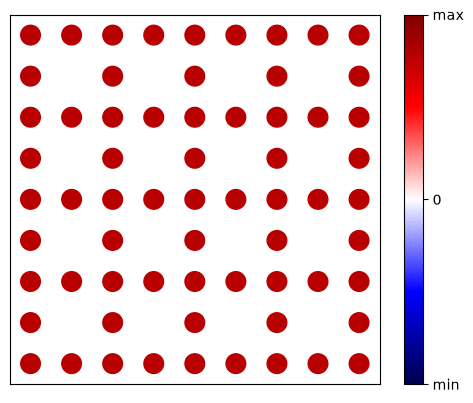

In [23]:
# cell to be run
prop.get_animation_nb(s=200)

## Adiabatic Pumping

In [24]:
lat = lattice(unit_cell=unit_cell, prim_vec=prim_vec)
n1, n2 = 7, 7
lat.get_lattice(n1=n1, n2=n2)
lat.remove_dangling()
sys = system(lat=lat)

### Configuration 1 (cross defect state bottom left)

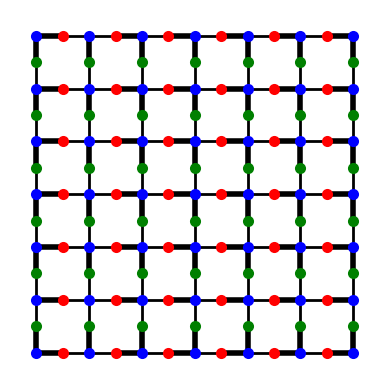

In [25]:
sys.set_hopping([{'n': 1, 'tag': 'ab', 't': t_ab},
                 {'n': 1, 'tag': 'ba', 't': t_ba},
                 {'n': 1, 'tag': 'ac', 't': t_ac},
                 {'n': 1, 'tag': 'ca', 't': t_ca}])
sys = system(lat=lat)
plt = plot(sys)
t_ab, t_ba = 4/3., 2/3.
t_ac, t_ca = 4/3., 2/3.
sys.set_hopping([{'n': 1, 'tag': 'ab', 't': t_ab},
                 {'n': 1, 'tag': 'ba', 't': t_ba},
                 {'n': 1, 'tag': 'ac', 't': t_ac},
                 {'n': 1, 'tag': 'ca', 't': t_ca}])
sys.set_onsite({'a': 0j, 'b': -2j, 'c': -2j})
# Dimerization along x
list_hop = [{'n': 1, 'tag': 'ab', 't': t_ba},
            {'n': 1, 'tag': 'ba', 't': t_ab}]
sys.change_hopping_square(list_hop=list_hop, 
                          xlims=[2., 14.], 
                          ylims=[0., 14.])
# Dimerization along y
list_hop = [{'n': 1, 'tag': 'ac', 't': t_ca},
            {'n': 1, 'tag': 'ca', 't': t_ac}]
sys.change_hopping_square(list_hop=list_hop,
                   xlims=[0., 14.], 
                   ylims=[2., 14.])
sys.get_ham()
ham1 = sys.ham
plt.lattice(ms=8, plt_hop=True);

### Configuration 2 (cross defect state bottom right)

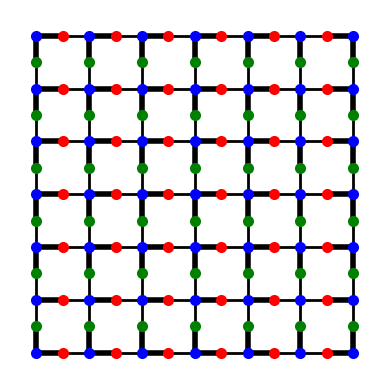

In [26]:
sys.set_hopping([{'n': 1, 'tag': 'ab', 't': t_ab},
                 {'n': 1, 'tag': 'ba', 't': t_ba},
                 {'n': 1, 'tag': 'ac', 't': t_ac},
                 {'n': 1, 'tag': 'ca', 't': t_ca}])
sys = system(lat=lat)
plt = plot(sys)
t_ab, t_ba = 4/3., 2/3.
t_ac, t_ca = 4/3., 2/3.
sys.set_hopping([{'n': 1, 'tag': 'ab', 't': t_ab},
                 {'n': 1, 'tag': 'ba', 't': t_ba},
                 {'n': 1, 'tag': 'ac', 't': t_ac},
                 {'n': 1, 'tag': 'ca', 't': t_ca}])
sys.set_onsite({'a': 0j, 'b': -2j, 'c': -2j})
# Dimerization along x
list_hop = [{'n': 1, 'tag': 'ab', 't': t_ba},
            {'n': 1, 'tag': 'ba', 't': t_ab}]
sys.change_hopping_square(list_hop=list_hop, 
                          xlims=[10., 12.], 
                          ylims=[0., 12.])
# Dimerization along y
list_hop = [{'n': 1, 'tag': 'ac', 't': t_ca},
            {'n': 1, 'tag': 'ca', 't': t_ac}]
sys.change_hopping_square(list_hop=list_hop,
                          xlims=[0., 12.], 
                          ylims=[2., 12.])
sys.get_ham()
ham2 = sys.ham
plt.lattice(ms=8, plt_hop=True);

### Configuration 3 (cross defect state top right)

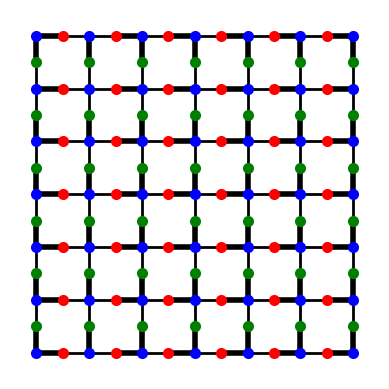

In [27]:
sys.set_hopping([{'n': 1, 'tag': 'ab', 't': t_ab},
                 {'n': 1, 'tag': 'ba', 't': t_ba},
                 {'n': 1, 'tag': 'ac', 't': t_ac},
                 {'n': 1, 'tag': 'ca', 't': t_ca}])
sys = system(lat=lat)
plt = plot(sys)
t_ab, t_ba = 4/3., 2/3.
t_ac, t_ca = 4/3., 2/3.
sys.set_hopping([{'n': 1, 'tag': 'ab', 't': t_ab},
                 {'n': 1, 'tag': 'ba', 't': t_ba},
                 {'n': 1, 'tag': 'ac', 't': t_ac},
                 {'n': 1, 'tag': 'ca', 't': t_ca}])
sys.set_onsite({'a': 0j, 'b': -2j, 'c': -2j})
# Dimerization along x
list_hop = [{'n': 1, 'tag': 'ab', 't': t_ba},
            {'n': 1, 'tag': 'ba', 't': t_ab}]
sys.change_hopping_square(list_hop=list_hop, 
                          xlims=[2., 12.], 
                          ylims=[0., 12.])
# Dimerization along y
list_hop = [{'n': 1, 'tag': 'ac', 't': t_ca},
            {'n': 1, 'tag': 'ca', 't': t_ac}]
sys.change_hopping_square(list_hop=list_hop,
                   xlims=[0., 12.], 
                   ylims=[10., 12.])
sys.get_ham()
ham3 = sys.ham
plt.lattice(ms=8, plt_hop=True);

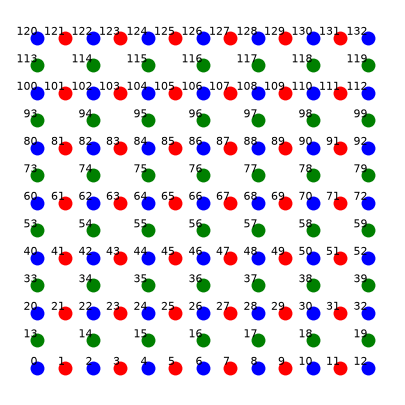

In [28]:
lat.plot(plt_index=True, ms=10, fs=8);

In [29]:
prop = propagation(lat=lat)
psi_init = np.zeros(lat.sites, 'c16')
psi_init[22] = 1.
prop.get_pumping(hams=[ham1, ham2, ham3], 
                     psi_init=psi_init,
                     steps=100, dz=0.5, norm=True)

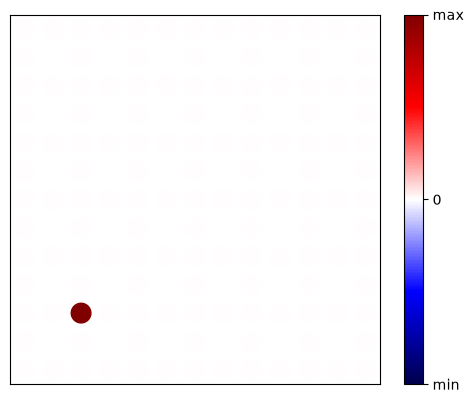

In [30]:
# cell to be run
prop.get_animation_nb(s=200)